# Introduction
This notebook tries to mimic the operation condition.
One should control the position of the motors and optics through the manipulation of the corresponding motion axes through the pre-defined functions.
In this way, one moves within the range permitted by the motor and respect the geometric constrain of the installation of the setup.

Initially, I thought I could move the installation operation to this notebook.
However, it seems that that is not very possible simply due to the complexity of the module.

#### Definition
1. um, fs, keV
2. normal is pointing inwards the reflection surface
3. The coordinate convention of this simulation and its relation to XPP coordinate is 
    (axis 0, axis 1, axis 2) = (vertical, horizontal, propagation) = (xpp y, xpp x, xpp z)
    i.e., The name in this code is x,y,z, using one convension. In the text, use the XPP convention 

np.fft(field) = spectrum

np.ifft(spectrum) = field

# Step 1: Ray Tracing Calculation

In [1]:
import time
import sys
sys.path.append("../../../../XRaySimulation")

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import patches

# Level 1 dependence
from XRaySimulation import Pulse, DeviceSimu, util

# Level 2 dependece
import parser
import Controller

plt.rcParams.update({'font.size': 14})

In [2]:
# Create the experiment setup
exp = Controller.XppController_TG()

Create a XA10A motor, moving along x axis.
Create a XA10A motor, moving along y axis.
Create a RA10A motor, rotating around y axis.
Create a SA07A motor, rotating around z axis.
Create a XA10A motor, moving along x axis.
Create a XA10A motor, moving along y axis.
Create a RA10A motor, rotating around y axis.
Create a SA07A motor, rotating around z axis.
Create a XA10A motor, moving along x axis.
Create a XA10A motor, moving along y axis.
Create a RA10A motor, rotating around y axis.
Create a SA07A motor, rotating around z axis.
Create a XA10A motor, moving along x axis.
Create a XA10A motor, moving along y axis.
Create a RA10A motor, rotating around y axis.
Create a SA07A motor, rotating around z axis.
Create a XA10A motor, moving along x axis.
Create a XA10A motor, moving along y axis.
Create a RA10A motor, rotating around y axis.
Create a SA07A motor, rotating around z axis.
Create a XA10A motor, moving along x axis.
Create a XA10A motor, moving along y axis.
Create a RA10A motor, ro

# Define functions on the fly

# Preparation: Align the mono

Motor moved from 0.00000 to -17.88927 degree
Motor moved from 0.00000 to -17.88927 degree
Motor moved from -17.88927 to -17.89074 degree
Motor moved from -17.88927 to -17.89076 degree


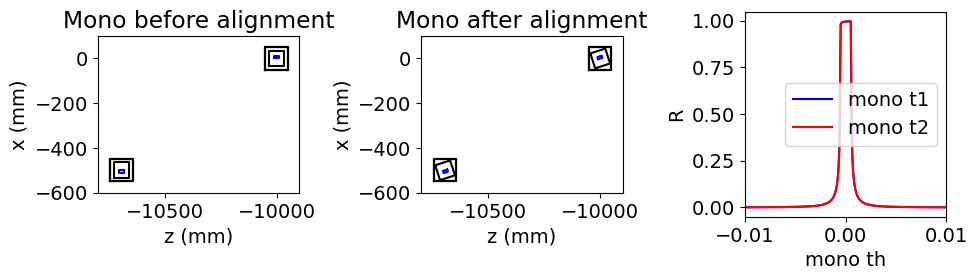

In [3]:
# Prepare a canvas. This section is not important. 
fig, ax = plt.subplots(ncols=3, nrows=1)
fig.set_figheight(3)
fig.set_figwidth(10)

exp.plot_motors(ax=ax[0], color='black')
exp.plot_optics(ax=ax[0], color='blue')

ax[0].set_aspect('equal')
ax[0].set_title("Mono before alignment")
ax[0].set_xlabel("z (mm)")
ax[0].set_ylabel("x (mm)")
ax[0].set_xlim([-10e3 - 800, -10e3 + 100])
ax[0].set_ylim([- 600, 100])

_ = exp.align_xpp_mono()
exp.plot_motors(ax=ax[1], color='black')
exp.plot_optics(ax=ax[1], color='blue')

ax[1].set_aspect('equal')
ax[1].set_title("Mono after alignment")
ax[1].set_xlabel("z (mm)")
ax[1].set_ylabel("x (mm)")
ax[1].set_xlim([-10e3 - 800, -10e3 + 100])
ax[1].set_ylim([- 600, 100])

ax[2].plot(np.rad2deg(exp.mono_t1_rocking[0]), exp.mono_t1_rocking[1], c='b', label='mono t1')
ax[2].plot(np.rad2deg(exp.mono_t2_rocking[0]), exp.mono_t1_rocking[1], c='r', label='mono t2')
ax[2].set_xlim([-0.01, 0.01])
ax[2].set_xlabel("mono th")
ax[2].set_ylabel("R")
ax[2].legend()

plt.tight_layout()
plt.show()

# Preparation: Align the miniSD

Motor moved from 0.00000 to 19.23525 degree
Motor moved from 0.00000 to -19.23525 degree
Motor moved from 0.00000 to 19.23525 degree
Motor moved from 0.00000 to 19.23525 degree
Motor moved from 0.00000 to -19.23525 degree
Motor moved from 0.00000 to -19.23525 degree
Motor moved from 19.23525 to 19.23630 degree
Motor moved from -19.23525 to -19.23608 degree
Motor moved from -19.23525 to -19.23594 degree
Motor moved from 19.23525 to 19.23715 degree
Motor moved from 19.23525 to 19.23721 degree
Motor moved from -19.23525 to -19.23581 degree


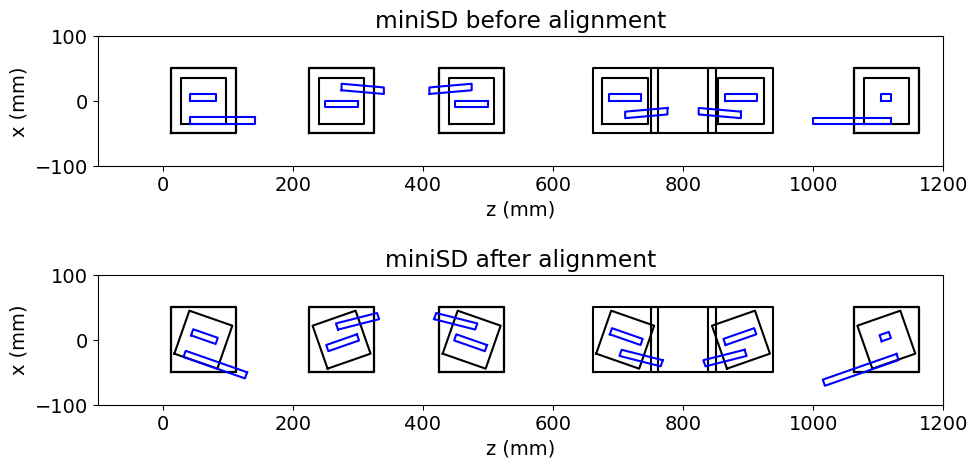

In [4]:
# Prepare a canvas. This section is not important. 
fig, ax = plt.subplots(ncols=1, nrows=2)
fig.set_figheight(5)
fig.set_figwidth(10)

# -----------------------------------------------
#     Before alignment
# -----------------------------------------------
exp.plot_motors(ax=ax[0], color='black')
exp.plot_optics(ax=ax[0], color='blue')
ax[0].set_aspect('equal')
ax[0].set_title("miniSD before alignment")
ax[0].set_xlabel("z (mm)")
ax[0].set_ylabel("x (mm)")
ax[0].set_xlim([-100, 1200])
ax[0].set_ylim([-100, 100])

# -----------------------------------------------
#     After alignment
# -----------------------------------------------
_ = exp.align_miniSD()

exp.plot_motors(ax=ax[1], color='black')
exp.plot_optics(ax=ax[1], color='blue')

ax[1].set_aspect('equal')
ax[1].set_title("miniSD after alignment")
ax[1].set_xlabel("z (mm)")
ax[1].set_ylabel("x (mm)")
ax[1].set_xlim([-100, 1200])
ax[1].set_ylim([-100, 100])

plt.tight_layout()
plt.show()

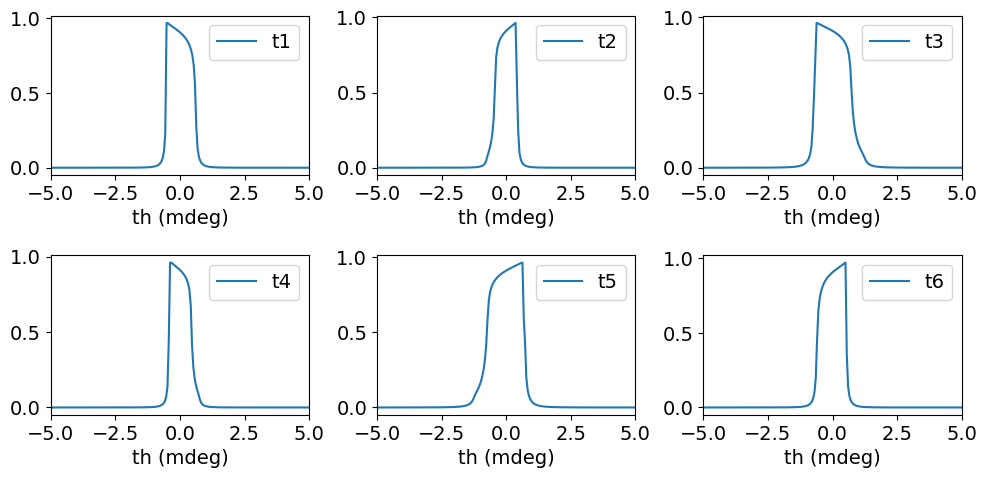

In [5]:
fig, ax = plt.subplots(ncols=3, nrows=2)
fig.set_figheight(5)
fig.set_figwidth(10)

record_to_plot = [exp.t1_rocking, exp.t2_rocking, exp.t3_rocking, exp.t4_rocking, exp.t5_rocking, exp.t6_rocking]
for idx in range(2):
    for idx2 in range(3):
        record = record_to_plot[idx2 + idx * 3]
        ax[idx, idx2].plot(np.rad2deg(record[0]) * 1000, record[1], label='t{}'.format(idx2 + 3 * idx + 1))
        ax[idx, idx2].set_xlabel('th (mdeg)')
        ax[idx, idx2].legend()
        ax[idx, idx2].set_xlim([-5, 5])
plt.tight_layout()
plt.show()

# Step 1: Find the X-ray pulse after miniSD on the downstream YAG after the miniSD

In [6]:
cc_traj, kout, cc_pathlength = exp.get_raytracing_trajectory(path="cc", get_path_length='True')
vcc_traj, kout, vcc_pathlength = exp.get_raytracing_trajectory(path="vcc", get_path_length='True')

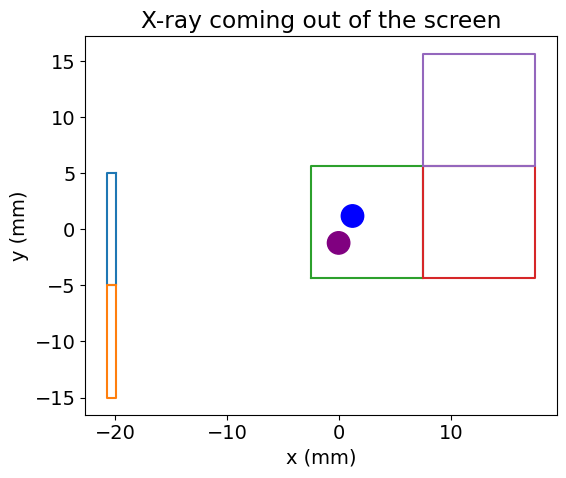

In [7]:
# Show the YAG boundaries and the CC pulse location on the YAG
fig, ax = plt.subplots(ncols=1, nrows=1)
fig.set_figheight(5)
fig.set_figwidth(10)

for item in exp.sample.all_optics:
    ax.plot(item.boundary[:,1]/1000, item.boundary[:,0]/1000,)
cc_spot = patches.Circle((cc_traj[-1][1] / 1e3, cc_traj[-1][0]/1e3), radius=1, color='blue')
vcc_spot = patches.Circle((vcc_traj[-1][1]/1e3, vcc_traj[-1][0]/1e3), radius=1, color='purple')
ax.add_patch(cc_spot)
ax.add_patch(vcc_spot)

ax.set_aspect('equal')
ax.set_title("X-ray coming out of the screen")
ax.set_xlabel("x (mm)")
ax.set_ylabel("y (mm)")

plt.tight_layout()
plt.show()

# Step 2: Align the probe beam such that it overlap with the CC beam
## Step 2a: Find the beam after the mirror 1 on the YAG


In [8]:
# Assume that we have calibrated the incident angle
_ = exp.m1.pi_umv(np.deg2rad(0.1))

# Move the mirror position such that the interaction point with the mirror is at location z=4e6
path_ref = exp.get_raytracing_trajectory(path="probe m1 only")
_ = exp.m1.y_umvr(100)
path_new = exp.get_raytracing_trajectory(path="probe m1 only")

coef = path_new[0][-2][2] - path_ref[0][-2][2]
total_diff = exp.m1.optics.surface_point[2] - path_new[0][-2][2]
print("Move the TG-a pulse {:.5f} um in y axis by moving m1y 100 um".format(coef))
print("Need to move m1y {:.5f} um to compensate the total difference of {:.5f} um".format(
    total_diff / coef * 100, total_diff))
_ = exp.m1.y_umvr(total_diff / coef * 100)

Motor moved from 0.00000 to 0.10000 degree
Motor moved from 0.0000 um to to 100.0000 um
Move the TG-a pulse -53208.66151 um in y axis by moving m1y 100 um
Need to move m1y -851.05816 um to compensate the total difference of 452836.65611 um
Motor moved from 100.0000 um to to -751.0582 um


In [9]:
probe_m1_traj, kout, probe_m1_pathlength = exp.get_raytracing_trajectory(path="probe m1 only", get_path_length='True')

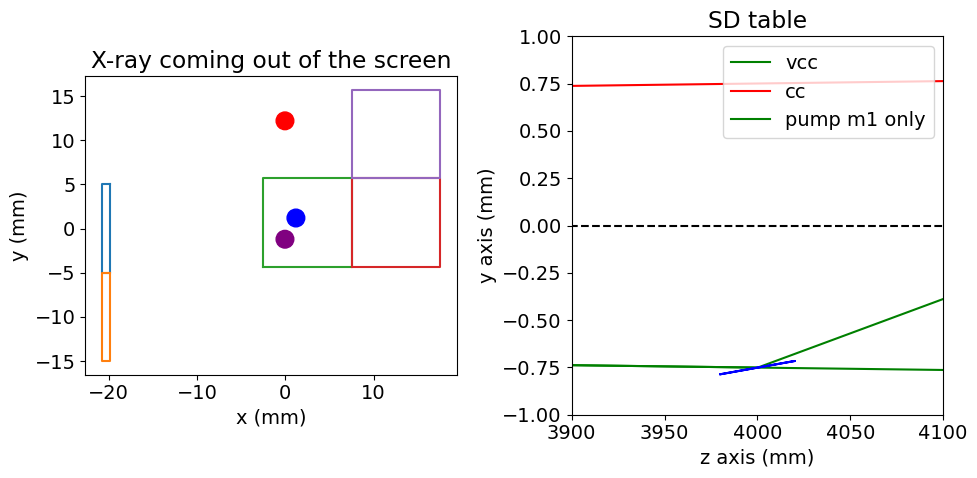

In [10]:
# Show the YAG boundaries and the CC pulse location on the YAG
fig, ax = plt.subplots(ncols=2, nrows=1)
fig.set_figheight(5)
fig.set_figwidth(10)

for item in exp.sample.all_optics:
    ax[0].plot(item.boundary[:,1]/1000, item.boundary[:,0]/1000,)
cc_spot = patches.Circle((cc_traj[-1][1] / 1e3, cc_traj[-1][0]/1e3), radius=1, color='blue')
vcc_spot = patches.Circle((vcc_traj[-1][1]/1e3, vcc_traj[-1][0]/1e3), radius=1, color='purple')
probe_m1_spot = patches.Circle((probe_m1_traj[-1][1]/1e3, probe_m1_traj[-1][0]/1e3), radius=1, color='red')
ax[0].add_patch(cc_spot)
ax[0].add_patch(vcc_spot)
ax[0].add_patch(probe_m1_spot)

ax[0].set_aspect('equal')
ax[0].set_title("X-ray coming out of the screen")
ax[0].set_xlabel("x (mm)")
ax[0].set_ylabel("y (mm)")

ax[1].plot(np.arange(-50, 10000), np.zeros(10050), c='k', linestyle='--')
ax[1].plot(vcc_traj[:,2] / 1e3, vcc_traj[:,0] / 1e3, 'g', label='vcc')
ax[1].plot(cc_traj[:,2] / 1e3, cc_traj[:,0] / 1e3, 'r', label='cc')
ax[1].plot(probe_m1_traj[:,2] / 1e3, probe_m1_traj[:,0] / 1e3, color='g', label='pump m1 only')
exp.plot_optics(ax=ax[1], axis='yz', color='blue')

ax[1].set_ylim([-1, 1])
ax[1].set_xlim([3900, 4100])
ax[1].set_xlabel("z axis (mm)")
ax[1].set_ylabel("y axis (mm)")
ax[1].set_title('SD table')
ax[1].legend()

plt.tight_layout()
plt.show()

## Step 2b Align the silicon 111 crystal

In [11]:
probe_old_traj, kout, probe_old_pathlength= exp.get_raytracing_trajectory(path="probe")

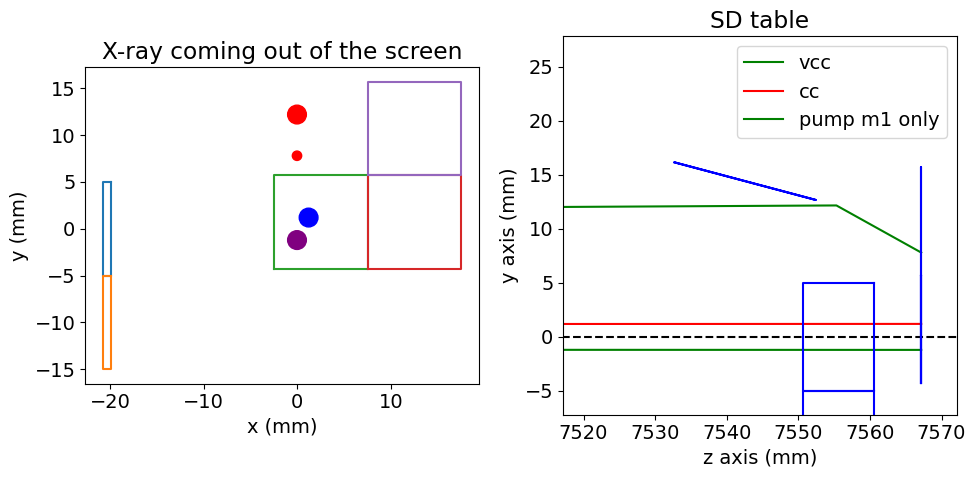

In [12]:
# Show the YAG boundaries and the CC pulse location on the YAG
fig, ax = plt.subplots(ncols=2, nrows=1)
fig.set_figheight(5)
fig.set_figwidth(10)

for item in exp.sample.all_optics:
    ax[0].plot(item.boundary[:,1]/1000, item.boundary[:,0]/1000,)
cc_spot = patches.Circle((cc_traj[-1][1] / 1e3, cc_traj[-1][0]/1e3), radius=1, color='blue')
vcc_spot = patches.Circle((vcc_traj[-1][1]/1e3, vcc_traj[-1][0]/1e3), radius=1, color='purple')
probe_m1_spot = patches.Circle((probe_m1_traj[-1][1]/1e3, probe_m1_traj[-1][0]/1e3), radius=1, color='red')
probe_old_spot = patches.Circle((probe_old_traj[-1][1]/1e3, probe_old_traj[-1][0]/1e3), radius=0.5, color='red')
ax[0].add_patch(cc_spot)
ax[0].add_patch(vcc_spot)
ax[0].add_patch(probe_m1_spot)
ax[0].add_patch(probe_old_spot)

ax[0].set_aspect('equal')
ax[0].set_title("X-ray coming out of the screen")
ax[0].set_xlabel("x (mm)")
ax[0].set_ylabel("y (mm)")

ax[1].plot(np.arange(-50, 10000), np.zeros(10050), c='k', linestyle='--')
ax[1].plot(vcc_traj[:,2] / 1e3, vcc_traj[:,0] / 1e3, 'g', label='vcc')
ax[1].plot(cc_traj[:,2] / 1e3, cc_traj[:,0] / 1e3, 'r', label='cc')
ax[1].plot(probe_old_traj[:,2] / 1e3, probe_old_traj[:,0] / 1e3, color='g', label='pump m1 only')
exp.plot_optics(ax=ax[1], axis='yz', color='blue')

ax[1].set_ylim([probe_old_traj[-1,0] / 1e3 - 15, probe_old_traj[-1,0] / 1e3 + 20])
ax[1].set_xlim([probe_old_traj[-1,2] / 1e3 - 50, probe_old_traj[-1,2] / 1e3 + 5])
ax[1].set_xlabel("z axis (mm)")
ax[1].set_ylabel("y axis (mm)")
ax[1].set_title('SD table')
ax[1].legend()

plt.tight_layout()
plt.show()

In [40]:
# During operation, we need to make sure first that the X-ray is hiting on the si 111 crsytal
# Get the theoretical Bragg angle
bragg_si111 = util.get_bragg_angle(wave_length=np.pi * 2 / exp.gaussian_pulse.klen0, plane_distance=Controller.si111['d'])

# Account for the 10 deg of the adaptor tilting
ang_diff = bragg_si111 - np.deg2rad(10)

# Rotate the crystal by the remaining angle
_ = exp.si.pi_umv(ang_diff)

# Get the rocking curve from this crystal
(angles1, reflect_sigma1,
 reflect_pi1, b_factor1, kout1) = DeviceSimu.get_rocking_curve_around_axis(
                                kin=exp.gaussian_pulse.k0,
                                scan_range=np.deg2rad(0.5),
                                scan_number=10 ** 4,
                                rotation_axis=exp.si.pi.rotation_axis,
                                h_initial=exp.si.optics.h,
                                normal_initial=exp.si.optics.normal,
                                thickness=exp.si.optics.thickness,
                                chi_dict=exp.si.optics.chi_dict, )

# Get the target bragg peak
fwhm, angle_adjust, index = util.get_fwhm(coordinate=angles1,
                                          curve_values=np.square(np.abs(reflect_pi1)),
                                          center=True,
                                          get_index=True)

# Move the crystal to the target path
_ = exp.si.pi_umv(target= exp.si.pi.control_location + angle_adjust)

Motor moved from 1.63948 to 1.63904 degree
Motor moved from 1.63904 to 1.64112 degree


In [42]:
probe_old_traj, kout, probe_old_pathlength= exp.get_raytracing_trajectory(path="probe")

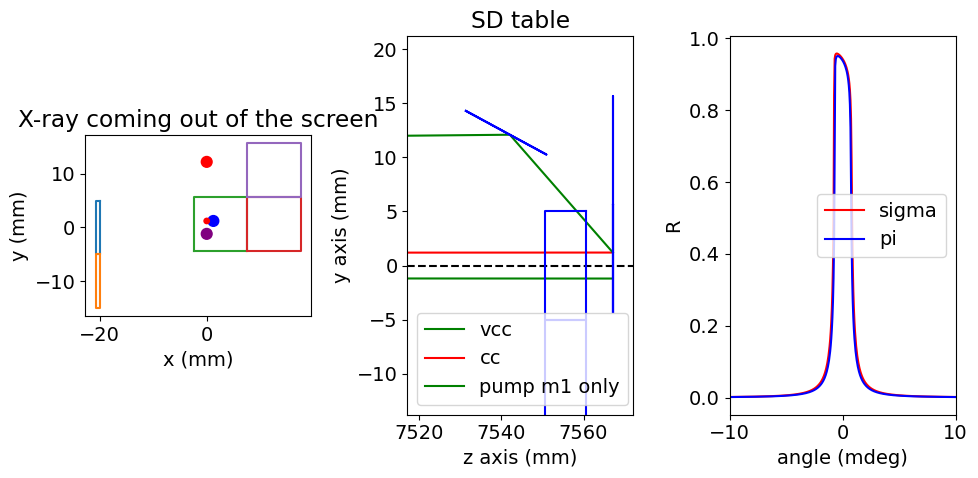

In [43]:
# Show the YAG boundaries and the CC pulse location on the YAG
fig, ax = plt.subplots(ncols=3, nrows=1)
fig.set_figheight(5)
fig.set_figwidth(10)

for item in exp.sample.all_optics:
    ax[0].plot(item.boundary[:,1]/1000, item.boundary[:,0]/1000,)
cc_spot = patches.Circle((cc_traj[-1][1] / 1e3, cc_traj[-1][0]/1e3), radius=1, color='blue')
vcc_spot = patches.Circle((vcc_traj[-1][1]/1e3, vcc_traj[-1][0]/1e3), radius=1, color='purple')
probe_m1_spot = patches.Circle((probe_m1_traj[-1][1]/1e3, probe_m1_traj[-1][0]/1e3), radius=1, color='green')
probe_old_spot = patches.Circle((probe_old_traj[-1][1]/1e3, probe_old_traj[-1][0]/1e3), radius=0.5, color='green')
ax[0].add_patch(cc_spot)
ax[0].add_patch(vcc_spot)
ax[0].add_patch(probe_m1_spot)
ax[0].add_patch(probe_old_spot)

ax[0].set_aspect('equal')
ax[0].set_title("X-ray coming out of the screen")
ax[0].set_xlabel("x (mm)")
ax[0].set_ylabel("y (mm)")

ax[1].plot(np.arange(-50, 10000), np.zeros(10050), c='k', linestyle='--')
ax[1].plot(vcc_traj[:,2] / 1e3, vcc_traj[:,0] / 1e3, 'g', label='vcc')
ax[1].plot(cc_traj[:,2] / 1e3, cc_traj[:,0] / 1e3, 'r', label='cc')
ax[1].plot(probe_old_traj[:,2] / 1e3, probe_old_traj[:,0] / 1e3, color='g', label='pump m1 only')
exp.plot_optics(ax=ax[1], axis='yz', color='blue')

ax[1].set_ylim([probe_old_traj[-1,0] / 1e3 - 15, probe_old_traj[-1,0] / 1e3 + 20])
ax[1].set_xlim([probe_old_traj[-1,2] / 1e3 - 50, probe_old_traj[-1,2] / 1e3 + 5])
ax[1].set_xlabel("z axis (mm)")
ax[1].set_ylabel("y axis (mm)")
ax[1].set_title('SD table')
ax[1].legend()

ax[2].plot(np.rad2deg(angles1 - angle_adjust) * 1000, np.square(np.abs(reflect_sigma1)), c='red', label='sigma')
ax[2].plot(np.rad2deg(angles1 - angle_adjust) * 1000, np.square(np.abs(reflect_pi1)), c='blue', label='pi')
ax[2].set_xlim([-10,10])
ax[2].set_xlabel("angle (mdeg)")
ax[2].set_ylabel("R")
ax[2].legend()

plt.tight_layout()
plt.show()

In [44]:
# Align the vertical overlap with the reference pump pulse
probe_old_traj, kout, probe_old_path = exp.get_raytracing_trajectory(path="probe")
_ = exp.si.y_umvr(100)
probe_new_traj, kout, probe_new_path = exp.get_raytracing_trajectory(path="probe")
pump_ref_traj, kout, pump_ref_path = exp.get_raytracing_trajectory(path="cc")

coef = probe_new_traj[-1][0] - probe_old_traj[-1][0]
total_diff = pump_ref_traj[-1][0] - probe_new_traj[-1][0]

print("Move the probe pulse {:.5f} um in y axis by moving siy 100 um".format(coef))
print("Need to move siy {:.5f} um to compensate the total difference of {:.5f} um".format(total_diff / coef * 100, total_diff))
_ = exp.si.y_umvr(total_diff / coef * 100)

Motor moved from -2387.7650 um to to -2287.7650 um
Move the probe pulse 209.05117 um in y axis by moving siy 100 um
Need to move siy -99.80430 um to compensate the total difference of -208.64205 um
Motor moved from -2287.7650 um to to -2387.5693 um


In [45]:
probe_traj, kout, probe_pathlength= exp.get_raytracing_trajectory(path="probe")

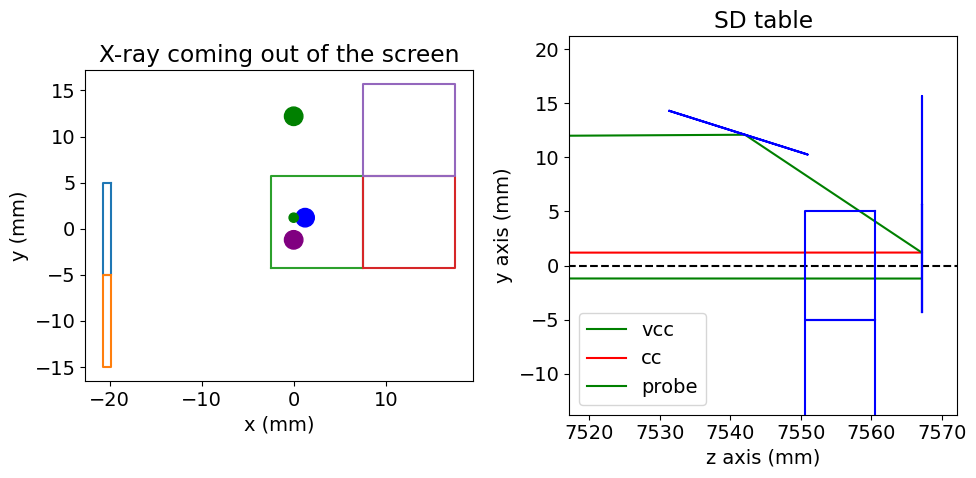

In [46]:
# Show the YAG boundaries and the CC pulse location on the YAG
fig, ax = plt.subplots(ncols=2, nrows=1)
fig.set_figheight(5)
fig.set_figwidth(10)

for item in exp.sample.all_optics:
    ax[0].plot(item.boundary[:,1]/1000, item.boundary[:,0]/1000,)
cc_spot = patches.Circle((cc_traj[-1][1] / 1e3, cc_traj[-1][0]/1e3), radius=1, color='blue')
vcc_spot = patches.Circle((vcc_traj[-1][1]/1e3, vcc_traj[-1][0]/1e3), radius=1, color='purple')
probe_m1_spot = patches.Circle((probe_m1_traj[-1][1]/1e3, probe_m1_traj[-1][0]/1e3), radius=1, color='green')
probe_traj_spot = patches.Circle((probe_traj[-1][1]/1e3, probe_traj[-1][0]/1e3), radius=0.5, color='green')
ax[0].add_patch(cc_spot)
ax[0].add_patch(vcc_spot)
ax[0].add_patch(probe_m1_spot)
ax[0].add_patch(probe_traj_spot)

ax[0].set_aspect('equal')
ax[0].set_title("X-ray coming out of the screen")
ax[0].set_xlabel("x (mm)")
ax[0].set_ylabel("y (mm)")

ax[1].plot(np.arange(-50, 10000), np.zeros(10050), c='k', linestyle='--')
ax[1].plot(vcc_traj[:,2] / 1e3, vcc_traj[:,0] / 1e3, 'g', label='vcc')
ax[1].plot(cc_traj[:,2] / 1e3, cc_traj[:,0] / 1e3, 'r', label='cc')
ax[1].plot(probe_traj[:,2] / 1e3, probe_traj[:,0] / 1e3, color='g', label='probe')
exp.plot_optics(ax=ax[1], axis='yz', color='blue')

ax[1].set_ylim([probe_traj[-1,0] / 1e3 - 15, probe_traj[-1,0] / 1e3 + 20])
ax[1].set_xlim([probe_traj[-1,2] / 1e3 - 50, probe_traj[-1,2] / 1e3 + 5])
ax[1].set_xlabel("z axis (mm)")
ax[1].set_ylabel("y axis (mm)")
ax[1].set_title('SD table')
ax[1].legend()

plt.tight_layout()
plt.show()

# Step 3: Align the total reflection mirrors for the pump pulse

In [47]:
_ = exp.m2a.yaw_umv(np.deg2rad(0.3))
_ = exp.m2a.x_umv(-9.5e3)

_ = exp.m2b.yaw_umv(np.deg2rad(-0.3))
_ = exp.m2b.x_umv(9966.5113)

Motor moved from 0.30000 to 0.30000 degree
Motor moved from -8413.4092 um to to -9500.0000 um
Motor moved from -0.30000 to -0.30000 degree
Motor moved from 10803.6900 um to to 9966.5113 um


In [ ]:
pump_a_no_mirror_traj, kout, pump_a_path = exp.get_raytracing_trajectory(path='pump a no mirror')
pump_a_traj, kout, pump_a_path = exp.get_raytracing_trajectory(path='pump a')
pump_b_no_mirror_traj, kout, pump_a_path = exp.get_raytracing_trajectory(path='pump b no mirror')
pump_b_traj, kout, pump_a_path = exp.get_raytracing_trajectory(path='pump b')

In [17]:
_ = exp.m1.pi_umv(np.deg2rad(0.1))

_ = exp.m2a.yaw_umv(np.deg2rad(0.3))
_ = exp.m2a.x_umv(-9.5e3)

_ = exp.m2b.yaw_umv(np.deg2rad(-0.3))
_ = exp.m2b.x_umv(9966.5113)

Motor moved from 0.10000 to 0.10000 degree
Motor moved from 0.30000 to 0.30000 degree
Motor moved from -9500.0000 um to to -9500.0000 um
Motor moved from -0.30000 to -0.30000 degree
Motor moved from 9966.5113 um to to 9966.5113 um


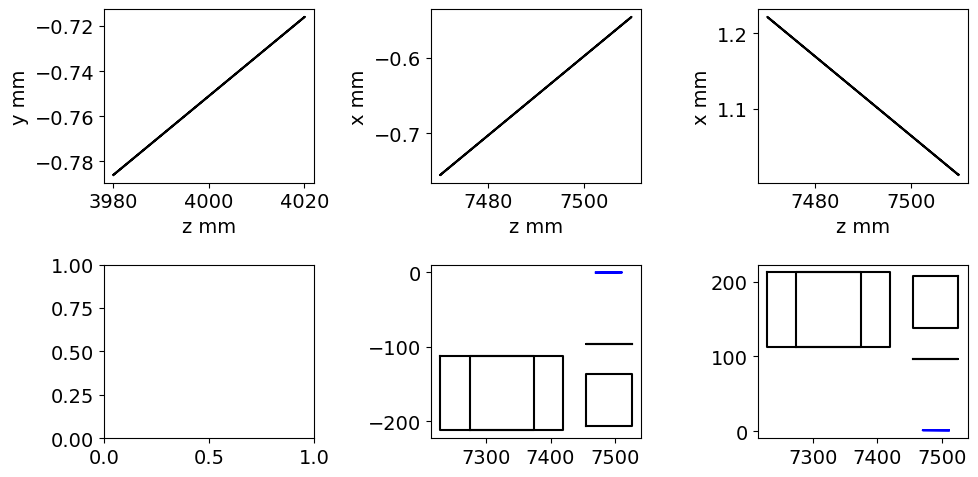

In [18]:
fig, ax = plt.subplots(ncols=3, nrows=2)
fig.set_figheight(5)
fig.set_figwidth(10)

for item in exp.m1.all_optics:
    ax[0,0].plot(item.boundary[:, 2] / 1000, item.boundary[:, 0] / 1000, c='black')
ax[0,0].set_xlabel("z mm")
ax[0,0].set_ylabel("y mm")

for item in exp.m2a.all_optics:
    ax[0,1].plot(item.boundary[:, 2] / 1000, item.boundary[:, 1] / 1000, c='black')
ax[0,1].set_xlabel("z mm")
ax[0,1].set_ylabel("x mm")

for item in exp.m2b.all_optics:
    ax[0,2].plot(item.boundary[:, 2] / 1000, item.boundary[:, 1] / 1000, c='black')
ax[0,2].set_xlabel("z mm")
ax[0,2].set_ylabel("x mm")


for item in exp.m2a.all_motors:
    ax[1,1].plot(item.boundary[:, 2] / 1000, item.boundary[:, 1] / 1000, c='black')
for item in exp.m2a.all_optics:
    ax[1,1].plot(item.boundary[:, 2] / 1000, item.boundary[:, 1] / 1000, c='blue')

for item in exp.m2b.all_motors:
    ax[1,2].plot(item.boundary[:, 2] / 1000, item.boundary[:, 1] / 1000, c='black')
for item in exp.m2b.all_optics:
    ax[1,2].plot(item.boundary[:, 2] / 1000, item.boundary[:, 1] / 1000, c='blue')


plt.tight_layout()
plt.show()


# Align the silicon crystal

In [19]:
# Get the theoretical Bragg angle
bragg_si111 = util.get_bragg_angle(wave_length=np.pi * 2 / exp.gaussian_pulse.klen0, plane_distance=Controller.si111['d'])

# Account for the 10 deg of the adaptor tilting
ang_diff = bragg_si111 - np.deg2rad(10)

# Rotate the crystal by the remaining angle
_ = exp.si.pi_umv(ang_diff)

# Get the rocking curve from this crystal
(angles1, reflect_sigma1,
 reflect_pi1, b_factor1, kout1) = DeviceSimu.get_rocking_curve_around_axis(
                                kin=exp.gaussian_pulse.k0,
                                scan_range=np.deg2rad(0.5),
                                scan_number=10 ** 4,
                                rotation_axis=exp.si.pi.rotation_axis,
                                h_initial=exp.si.optics.h,
                                normal_initial=exp.si.optics.normal,
                                thickness=exp.si.optics.thickness,
                                chi_dict=exp.si.optics.chi_dict, )

# Get the target bragg peak
fwhm, angle_adjust, index = util.get_fwhm(coordinate=angles1,
                                          curve_values=np.square(np.abs(reflect_pi1)),
                                          center=True,
                                          get_index=True)

# Move the crystal to the target path
_ = exp.si.pi_umv(target= exp.si.pi.control_location + angle_adjust)

Motor moved from 0.00000 to 1.63904 degree
Motor moved from 1.63904 to 1.63948 degree


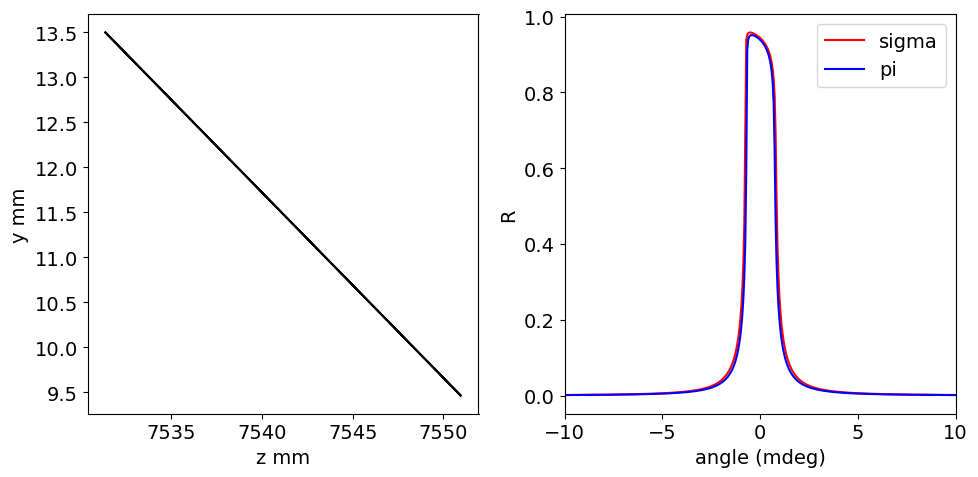

In [20]:
fig, ax = plt.subplots(ncols=2, nrows=1)
fig.set_figheight(5)
fig.set_figwidth(10)

for item in exp.si.all_optics:
    ax[0].plot(item.boundary[:, 2] / 1000, item.boundary[:, 0] / 1000, c='black')
ax[0].set_xlabel("z mm")
ax[0].set_ylabel("y mm")

ax[1].plot(np.rad2deg(angles1 - angle_adjust) * 1000, np.square(np.abs(reflect_sigma1)), c='red', label='sigma')
ax[1].plot(np.rad2deg(angles1 - angle_adjust) * 1000, np.square(np.abs(reflect_pi1)), c='blue', label='pi')
ax[1].set_xlim([-10,10])
ax[1].set_xlabel("angle (mdeg)")
ax[1].set_ylabel("R")
ax[1].legend()

plt.tight_layout()
plt.show()


# Calculate the ray-tracing trajectory and finely adjust the position of the motors.

In [21]:
probe_path1 = exp.get_raytracing_trajectory(path="mono SD m1 yag")
probe_path2 = exp.get_raytracing_trajectory(path="mono SD m1 si yag")
pump_path = exp.get_raytracing_trajectory(path="mono SD yag")
pump_path1 = exp.get_raytracing_trajectory(path="mono SD tga yag")
pump_path2 = exp.get_raytracing_trajectory(path="mono SD tga m2a yag")
pump_path3 = exp.get_raytracing_trajectory(path="mono SD tgb yag")
pump_path4 = exp.get_raytracing_trajectory(path="mono SD tgb m2b yag")

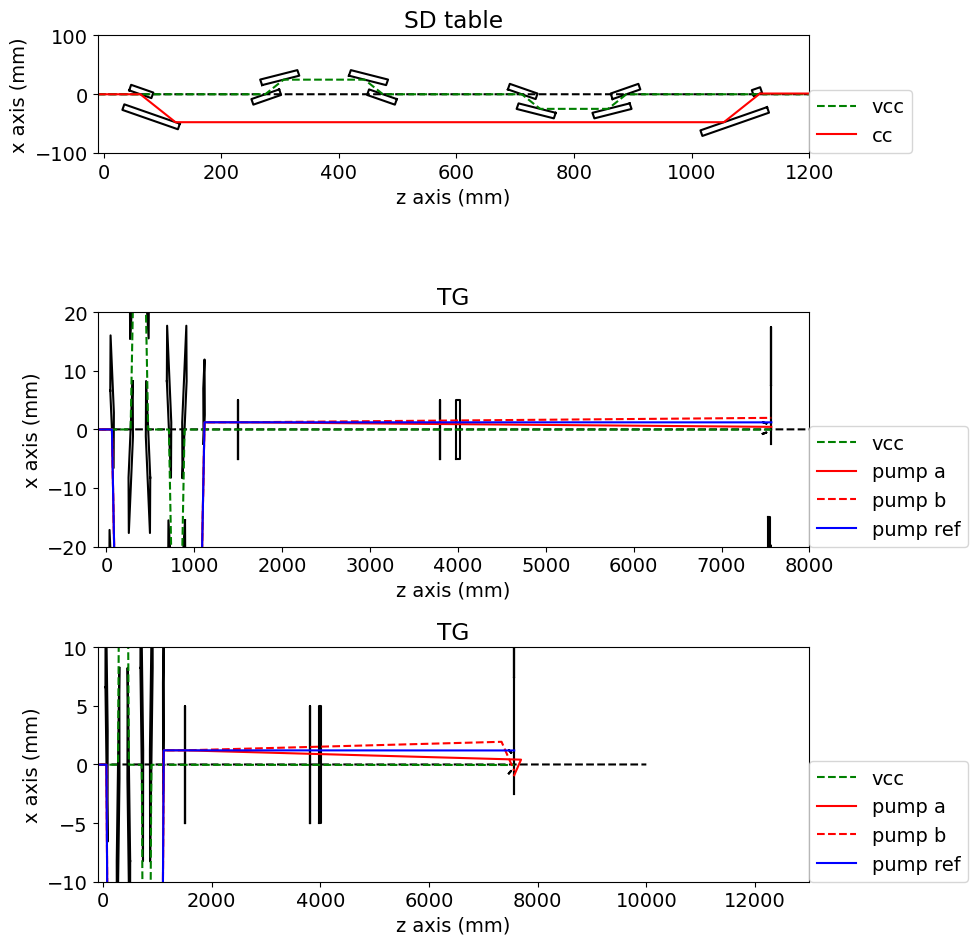

In [22]:
fig, axes = plt.subplots(ncols=1, nrows=3)

fig.set_figheight(10)
fig.set_figwidth(10)

axes[0].plot(np.arange(-50, 10000), np.zeros(10050), c='k', linestyle='--')
exp.plot_optics(ax=axes[0])

axes[0].plot(probe_path1[0][:,2] / 1e3, probe_path1[0][:,1] / 1e3, 'g--', label='vcc')
axes[0].plot(pump_path1[0][:,2] / 1e3, pump_path1[0][:,1] / 1e3, color='r', label='cc')

axes[0].set_aspect("equal")
axes[0].set_ylim([-100, 100])
axes[0].set_xlim([-10, 1200])
axes[0].set_xlabel("z axis (mm)")
axes[0].set_ylabel("x axis (mm)")
axes[0].set_title('SD table')
axes[0].legend(loc=(1,0))


axes[1].plot(np.arange(-50, 10000), np.zeros(10050), c='k', linestyle='--')
exp.plot_optics(ax=axes[1])

axes[1].plot(probe_path1[0][:,2] / 1e3, probe_path1[0][:,1] / 1e3, 'g--', label='vcc')
axes[1].plot(pump_path1[0][:,2] / 1e3, pump_path1[0][:,1] / 1e3, color='r', label='pump a')
axes[1].plot(pump_path3[0][:,2] / 1e3, pump_path3[0][:,1] / 1e3, linestyle='--', color='r', label='pump b')
axes[1].plot(pump_path[0][:,2] / 1e3, pump_path[0][:,1] / 1e3, color='b', label='pump ref')

#axes[1].set_aspect("equal")
axes[1].set_ylim([-20, 20])
axes[1].set_xlim([-100, 8000])
axes[1].set_xlabel("z axis (mm)")
axes[1].set_ylabel("x axis (mm)")
axes[1].set_title('TG')
axes[1].legend(loc=(1,0))


axes[2].plot(np.arange(-50, 10000), np.zeros(10050), c='k', linestyle='--')
exp.plot_optics(ax=axes[2])

axes[2].plot(probe_path1[0][:,2] / 1e3, probe_path1[0][:,1] / 1e3, 'g--', label='vcc')
axes[2].plot(pump_path2[0][:,2] / 1e3, pump_path2[0][:,1] / 1e3, color='r', label='pump a')
axes[2].plot(pump_path4[0][:,2] / 1e3, pump_path4[0][:,1] / 1e3, linestyle='--', color='r', label='pump b')
axes[2].plot(pump_path[0][:,2] / 1e3, pump_path[0][:,1] / 1e3, color='b', label='pump ref')

#axes[1].set_aspect("equal")
axes[2].set_ylim([-10, 10])
axes[2].set_xlim([-100, 13000])
axes[2].set_xlabel("z axis (mm)")
axes[2].set_ylabel("x axis (mm)")
axes[2].set_title('TG')
axes[2].legend(loc=(1,0))

plt.tight_layout()

# Get the dependence of the trajectory on the mirror position

In [23]:
probe_path1 = exp.get_raytracing_trajectory(path="mono SD m1 yag")
probe_path2 = exp.get_raytracing_trajectory(path="mono SD m1 si yag")
pump_path = exp.get_raytracing_trajectory(path="mono SD yag")
pump_path1 = exp.get_raytracing_trajectory(path="mono SD tga yag")
pump_path2 = exp.get_raytracing_trajectory(path="mono SD tga m2a yag")
pump_path3 = exp.get_raytracing_trajectory(path="mono SD tgb yag")
pump_path4 = exp.get_raytracing_trajectory(path="mono SD tgb m2b yag")

In [24]:
print("Get trajectory a")
_ = exp.m2a.x_umvr(100)
pump_path2_adjust = exp.get_raytracing_trajectory(path="mono SD tga m2a yag")
# Get the ratio
delta_x_per_um_in_x = pump_path2_adjust[0][-1][1] - pump_path2[0][-1][1]
total_diff = pump_path[0][-1][1] - pump_path2_adjust[0][-1][1]
print("Move the TG-a pulse {:.5f} um in x axis by moving m2a_x 100 um".format(delta_x_per_um_in_x))
print("Need to move m2a_x {:.5f} um to compensate the total difference of {:.5f} um".format(total_diff / delta_x_per_um_in_x * 100, 
                                                                                            total_diff))
_ = exp.m2a.x_umvr(total_diff / delta_x_per_um_in_x * 100)

print("\n ")

print("Get trajectory b")
_ = exp.m2b.x_umvr(100)
pump_path4_adjust = exp.get_raytracing_trajectory(path="mono SD tgb m2b yag")
delta_x_per_um_in_x = pump_path4_adjust[0][-1][1] - pump_path4[0][-1][1]
total_diff = pump_path[0][-1][1] - pump_path4_adjust[0][-1][1]
print("Move the TG-a pulse {:.5f} um in x axis by moving m2a_x 100 um".format(delta_x_per_um_in_x))
print("Need to move m2a_x {:.5f} um to compensate the total difference of {:.5f} um".format(total_diff / delta_x_per_um_in_x * 100, 
                                                                                            total_diff))
_ = exp.m2b.x_umvr(total_diff / delta_x_per_um_in_x * 100)

Get trajectory a
Motor moved from -9500.0000 um to to -9400.0000 um
Move the TG-a pulse 200.08356 um in x axis by moving m2a_x 100 um
Need to move m2a_x 957.30762 um to compensate the total difference of 1915.41521 um
Motor moved from -9400.0000 um to to -8442.6924 um

 
Get trajectory b
Motor moved from 9966.5113 um to to 10066.5113 um
Move the TG-a pulse 199.81594 um in x axis by moving m2a_x 100 um
Need to move m2a_x 766.42307 um to compensate the total difference of 1531.43549 um
Motor moved from 10066.5113 um to to 10832.9344 um


### This analysis shows that with the motor accuracy, we cannot achieve the desirable overlap with the motor motion only.

In [25]:
probe_path1 = exp.get_raytracing_trajectory(path="mono SD m1 yag")
probe_path2 = exp.get_raytracing_trajectory(path="mono SD m1 si yag")
pump_path = exp.get_raytracing_trajectory(path="mono SD yag")
pump_path1 = exp.get_raytracing_trajectory(path="mono SD tga yag")
pump_path2 = exp.get_raytracing_trajectory(path="mono SD tga m2a yag")
pump_path3 = exp.get_raytracing_trajectory(path="mono SD tgb yag")
pump_path4 = exp.get_raytracing_trajectory(path="mono SD tgb m2b yag")

In [26]:
print("Get trajectory a")
_ = exp.m2a.z_umvr(100)
pump_path2_adjust = exp.get_raytracing_trajectory(path="mono SD tga m2a yag")
# Get the ratio
delta_x_per_um_in_x = pump_path2_adjust[0][-1][1] - pump_path2[0][-1][1]
total_diff = pump_path[0][-1][1] - pump_path2_adjust[0][-1][1]
print("Move the TG-a pulse {:.5f} um in x axis by moving m2a_z 100 um".format(delta_x_per_um_in_x))
print("Need to move m2a_z {:.5f} um to compensate the total difference of {:.5f} um".format(total_diff / delta_x_per_um_in_x * 100, 
                                                                                            total_diff))
_ = exp.m2a.z_umvr(total_diff / delta_x_per_um_in_x * 100)

print("\n ")

print("Get trajectory b")
_ = exp.m2b.z_umvr(100)
pump_path4_adjust = exp.get_raytracing_trajectory(path="mono SD tgb m2b yag")
delta_x_per_um_in_x = pump_path4_adjust[0][-1][1] - pump_path4[0][-1][1]
total_diff = pump_path[0][-1][1] - pump_path4_adjust[0][-1][1]
print("Move the TG-a pulse {:.5f} um in x axis by moving m2a_z 100 um".format(delta_x_per_um_in_x))
print("Need to move m2a_z {:.5f} um to compensate the total difference of {:.5f} um".format(total_diff / delta_x_per_um_in_x * 100, 
                                                                                            total_diff))
_ = exp.m2b.z_umvr(total_diff / delta_x_per_um_in_x * 100)

Get trajectory a
Motor moved from 0.0000 um to to 100.0000 um
Move the TG-a pulse -1.05378 um in x axis by moving m2a_z 100 um
Need to move m2a_z -24.97198 um to compensate the total difference of 0.26315 um
Motor moved from 100.0000 um to to 75.0280 um

 
Get trajectory b
Motor moved from 0.0000 um to to 100.0000 um
Move the TG-a pulse 1.04371 um in x axis by moving m2a_z 100 um
Need to move m2a_z -148.63699 um to compensate the total difference of -1.55133 um
Motor moved from 100.0000 um to to -48.6370 um


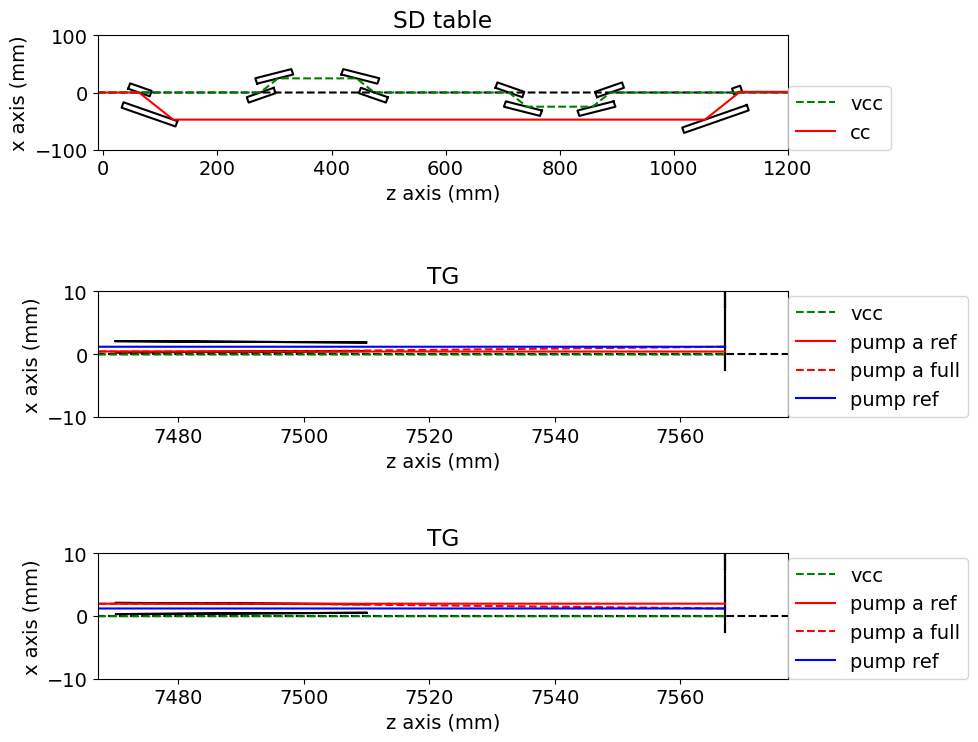

In [27]:
fig, axes = plt.subplots(ncols=1, nrows=3)

fig.set_figheight(8)
fig.set_figwidth(10)

axes[0].plot(np.arange(-50, 10000), np.zeros(10050), c='k', linestyle='--')
exp.plot_optics(ax=axes[0])

axes[0].plot(probe_path1[0][:,2] / 1e3, probe_path1[0][:,1] / 1e3, 'g--', label='vcc')
axes[0].plot(pump_path1[0][:,2] / 1e3, pump_path1[0][:,1] / 1e3, color='r', label='cc')

axes[0].set_aspect("equal")
axes[0].set_ylim([-100, 100])
axes[0].set_xlim([-10, 1200])
axes[0].set_xlabel("z axis (mm)")
axes[0].set_ylabel("x axis (mm)")
axes[0].set_title('SD table')
axes[0].legend(loc=(1,0))


axes[1].plot(np.arange(-50, 10000), np.zeros(10050), c='k', linestyle='--')
exp.plot_optics(ax=axes[1])

axes[1].plot(probe_path1[0][:,2] / 1e3, probe_path1[0][:,1] / 1e3, 'g--', label='vcc')
axes[1].plot(pump_path1[0][:,2] / 1e3, pump_path1[0][:,1] / 1e3, color='r', label='pump a ref')
axes[1].plot(pump_path2[0][:,2] / 1e3, pump_path2[0][:,1] / 1e3, linestyle='--', color='r', label='pump a full')
axes[1].plot(pump_path[0][:,2] / 1e3, pump_path[0][:,1] / 1e3, color='b', label='pump ref')

axes[1].set_aspect("equal")
axes[1].set_ylim([-10, 10])
axes[1].set_xlim([pump_path1[0][-1,2] / 1e3 - 100, pump_path1[0][-1,2] / 1e3 + 10])
axes[1].set_xlabel("z axis (mm)")
axes[1].set_ylabel("x axis (mm)")
axes[1].set_title('TG')
axes[1].legend(loc=(1,0))


axes[2].plot(np.arange(-50, 10000), np.zeros(10050), c='k', linestyle='--')
exp.plot_optics(ax=axes[2])

axes[2].plot(probe_path1[0][:,2] / 1e3, probe_path1[0][:,1] / 1e3, 'g--', label='vcc')
axes[2].plot(pump_path3[0][:,2] / 1e3, pump_path3[0][:,1] / 1e3, color='r', label='pump a ref')
axes[2].plot(pump_path4[0][:,2] / 1e3, pump_path4[0][:,1] / 1e3, linestyle='--', color='r', label='pump a full')
axes[2].plot(pump_path[0][:,2] / 1e3, pump_path[0][:,1] / 1e3, color='b', label='pump ref')

axes[2].set_ylim([-10, 10])
axes[2].set_aspect("equal")
axes[2].set_xlim([pump_path1[0][-1,2] / 1e3 - 100, pump_path1[0][-1,2] / 1e3 + 10])
axes[2].set_xlabel("z axis (mm)")
axes[2].set_ylabel("x axis (mm)")
axes[2].set_title('TG')
axes[2].legend(loc=(1,0))

plt.tight_layout()

# Shift the mirror such that the interaction point is on the mirror

In [28]:
diff = pump_path2[0][-2] - exp.m2a.optics.surface_point
exp.m2a.x_umvr(diff[1])
exp.m2a.z_umvr(diff[2])

Motor moved from -8442.6924 um to to -8413.4092 um
Motor moved from 75.0280 um to to 5588.0300 um


In [29]:
diff = pump_path4[0][-2] - exp.m2b.optics.surface_point
exp.m2b.x_umvr(diff[1])
exp.m2b.z_umvr(diff[2])

Motor moved from 10832.9344 um to to 10803.6900 um
Motor moved from -48.6370 um to to 5587.5174 um


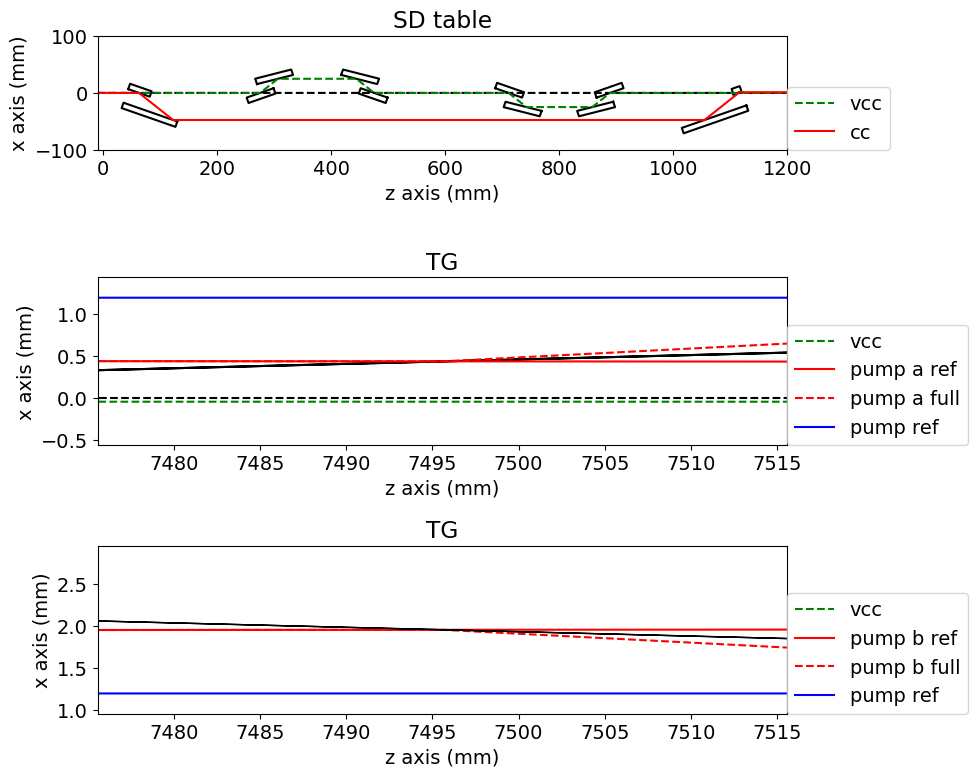

In [30]:
fig, axes = plt.subplots(ncols=1, nrows=3)

fig.set_figheight(8)
fig.set_figwidth(10)

axes[0].plot(np.arange(-50, 10000), np.zeros(10050), c='k', linestyle='--')
exp.plot_optics(ax=axes[0])

axes[0].plot(probe_path1[0][:,2] / 1e3, probe_path1[0][:,1] / 1e3, 'g--', label='vcc')
axes[0].plot(pump_path1[0][:,2] / 1e3, pump_path1[0][:,1] / 1e3, color='r', label='cc')

axes[0].set_aspect("equal")
axes[0].set_ylim([-100, 100])
axes[0].set_xlim([-10, 1200])
axes[0].set_xlabel("z axis (mm)")
axes[0].set_ylabel("x axis (mm)")
axes[0].set_title('SD table')
axes[0].legend(loc=(1,0))


axes[1].plot(np.arange(-50, 10000), np.zeros(10050), c='k', linestyle='--')
exp.plot_optics(ax=axes[1])
axes[1].plot(probe_path1[0][:,2] / 1e3, probe_path1[0][:,1] / 1e3, 'g--', label='vcc')
axes[1].plot(pump_path1[0][:,2] / 1e3, pump_path1[0][:,1] / 1e3, color='r', label='pump a ref')
axes[1].plot(pump_path2[0][:,2] / 1e3, pump_path2[0][:,1] / 1e3, linestyle='--', color='r', label='pump a full')
axes[1].plot(pump_path[0][:,2] / 1e3, pump_path[0][:,1] / 1e3, color='b', label='pump ref')
axes[1].set_ylim([pump_path2[0][-2,1] / 1e3 - 1, pump_path2[0][-2,1] / 1e3 + 1])
axes[1].set_xlim([pump_path2[0][-2,2] / 1e3 - 20, pump_path2[0][-2,2] / 1e3 + 20])
axes[1].set_xlabel("z axis (mm)")
axes[1].set_ylabel("x axis (mm)")
axes[1].set_title('TG')
axes[1].legend(loc=(1,0))


axes[2].plot(probe_path1[0][:,2] / 1e3, probe_path1[0][:,1] / 1e3, 'g--', label='vcc')
axes[2].plot(pump_path3[0][:,2] / 1e3, pump_path3[0][:,1] / 1e3, color='r', label='pump b ref')
axes[2].plot(pump_path4[0][:,2] / 1e3, pump_path4[0][:,1] / 1e3, linestyle='--', color='r', label='pump b full')
axes[2].plot(pump_path[0][:,2] / 1e3, pump_path[0][:,1] / 1e3, color='b', label='pump ref')
axes[2].plot(exp.m2b.optics.boundary[:,2] / 1000,exp.m2b.optics.boundary[:,1]/1000, color='k', linewidth=1)
axes[2].set_ylim([pump_path4[0][-2,1] / 1e3 - 1, pump_path4[0][-2,1] / 1e3 + 1])
axes[2].set_xlim([pump_path4[0][-2,2] / 1e3 - 20, pump_path4[0][-2,2] / 1e3 + 20])
axes[2].set_xlabel("z axis (mm)")
axes[2].set_ylabel("x axis (mm)")
axes[2].set_title('TG')
axes[2].legend(loc=(1,0))

plt.tight_layout()

# Now begin to work with the probe beam

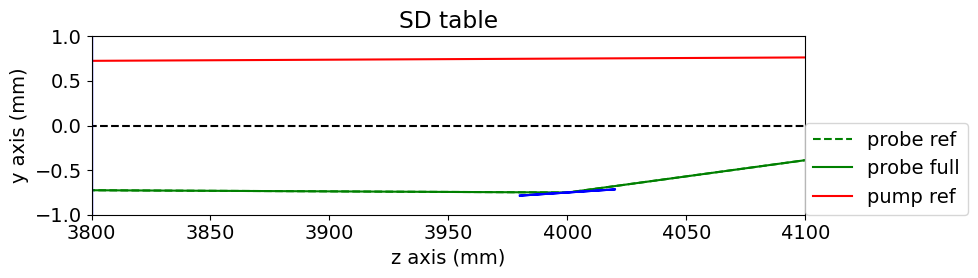

In [31]:
fig, axes = plt.subplots(ncols=1, nrows=1)

fig.set_figheight(3)
fig.set_figwidth(10)

axes.plot(np.arange(-50, 10000), np.zeros(10050), c='k', linestyle='--')
axes.plot(probe_path1[0][:,2] / 1e3, probe_path1[0][:,0] / 1e3, 'g--', label='probe ref')
axes.plot(probe_path2[0][:,2] / 1e3, probe_path2[0][:,0] / 1e3, color='g', label='probe full')
axes.plot(pump_path[0][:,2] / 1e3, pump_path[0][:,0] / 1e3, color='r', label='pump ref')
exp.plot_optics(ax=axes, axis='yz', color='blue')

axes.set_ylim([-1, 1])
axes.set_xlim([3800, 4100])
axes.set_xlabel("z axis (mm)")
axes.set_ylabel("y axis (mm)")
axes.set_title('SD table')
axes.legend(loc=(1,0))


plt.tight_layout()

# Move M1 such that the interaction point with the mirror is at location z=4e6

In [32]:
path_ref = exp.get_raytracing_trajectory(path="mono SD m1 yag")
_ = exp.m1.y_umvr(-100)
path_new = exp.get_raytracing_trajectory(path="mono SD m1 yag")

delta_100um = path_new[0][-2][2] - path_ref[0][-2][2]
total_diff = exp.m1.optics.surface_point[2] - path_new[0][-2][2]
print("Move the TG-a pulse {:.5f} um in x axis by moving m1y 100 um".format(delta_100um))
print("Need to move m1y {:.5f} um to compensate the total difference of {:.5f} um".format(
    total_diff / delta_100um * 100, total_diff))
_ = exp.m1.y_umvr(-total_diff / delta_100um * 100)

Motor moved from -751.0582 um to to -851.0582 um
Move the TG-a pulse 53254.52895 um in x axis by moving m1y 100 um
Need to move m1y -100.19747 um to compensate the total difference of -53359.69128 um
Motor moved from -851.0582 um to to -750.8607 um


In [33]:
path_ref = exp.get_raytracing_trajectory(path="mono SD m1 yag")

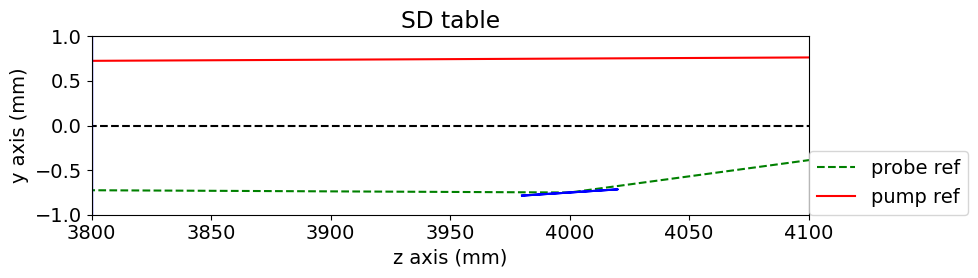

In [34]:
fig, axes = plt.subplots(ncols=1, nrows=1)

fig.set_figheight(3)
fig.set_figwidth(10)

axes.plot(np.arange(-50, 10000), np.zeros(10050), c='k', linestyle='--')
axes.plot(path_ref[0][:,2] / 1e3, path_ref[0][:,0] / 1e3, 'g--', label='probe ref')
axes.plot(pump_path[0][:,2] / 1e3, pump_path[0][:,0] / 1e3, color='r', label='pump ref')
exp.plot_optics(ax=axes, axis='yz', color='blue')

axes.set_ylim([-1, 1])
axes.set_xlim([3800, 4100])
axes.set_xlabel("z axis (mm)")
axes.set_ylabel("y axis (mm)")
axes.set_title('SD table')
axes.legend(loc=(1,0))


plt.tight_layout()

# Now need to worry about the silicon sample

In [35]:
probe_si_old = exp.get_raytracing_trajectory(path="mono SD m1 si yag")

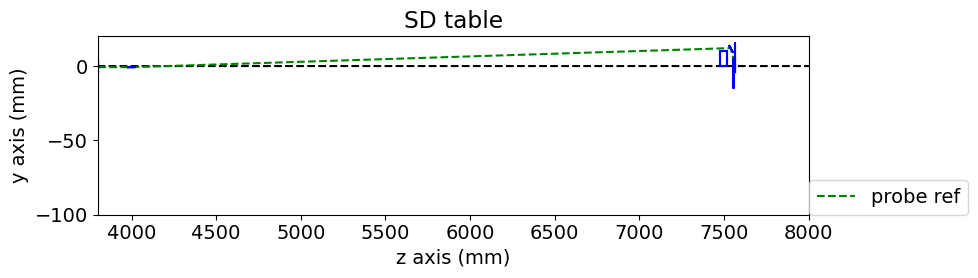

In [36]:
fig, axes = plt.subplots(ncols=1, nrows=1)

fig.set_figheight(3)
fig.set_figwidth(10)

axes.plot(np.arange(-50, 10000), np.zeros(10050), c='k', linestyle='--')
axes.plot(probe_si_old[0][:,2] / 1e3, probe_si_old[0][:,0] / 1e3, 'g--', label='probe ref')
exp.plot_optics(ax=axes, axis='yz', color='blue')

axes.set_ylim([-100, 20])
axes.set_xlim([3800, 8000])
axes.set_xlabel("z axis (mm)")
axes.set_ylabel("y axis (mm)")
axes.set_title('SD table')
axes.legend(loc=(1,0))


plt.tight_layout()

In [37]:
path_ref = exp.get_raytracing_trajectory(path="mono SD m1 si yag")
_ = exp.si.y_umvr(100)
path_new = exp.get_raytracing_trajectory(path="mono SD m1 si yag")
probe_pulse_ref = exp.get_raytracing_trajectory(path="mono SD yag")

delta_100um = path_new[0][-1][0] - path_ref[0][-1][0]
total_diff = probe_pulse_ref[0][-1][0] - path_new[0][-1][0]

print("Move the TG-a pulse {:.5f} um in x axis by moving m1y 100 um".format(delta_100um))
print("Need to move m1y {:.5f} um to compensate the total difference of {:.5f} um".format(total_diff / delta_100um * 100, total_diff))
_ = exp.si.y_umvr(total_diff / delta_100um * 100)

Motor moved from -3193.9904 um to to -3093.9904 um
Move the TG-a pulse 209.03451 um in x axis by moving m1y 100 um
Need to move m1y 706.22535 um to compensate the total difference of 1476.25471 um
Motor moved from -3093.9904 um to to -2387.7650 um


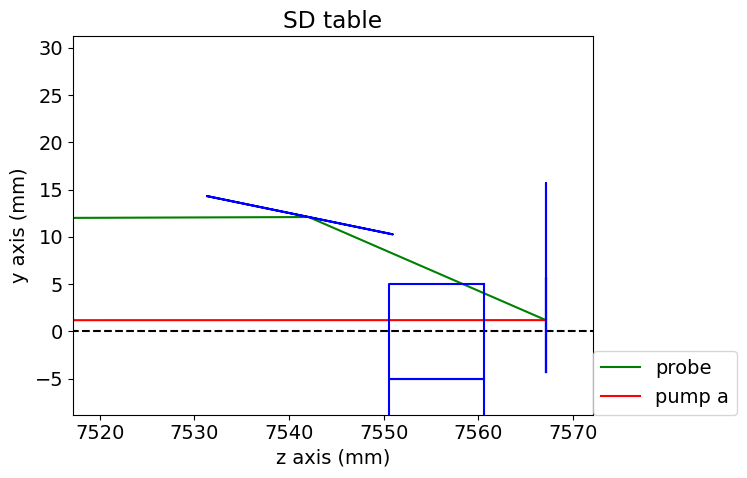

In [38]:
probe_si_new = exp.get_raytracing_trajectory(path="mono SD m1 si yag")
pump_path_new = exp.get_raytracing_trajectory(path="mono SD tga m2a yag")

fig, axes = plt.subplots(ncols=1, nrows=1)

fig.set_figheight(5)
fig.set_figwidth(10)

axes.plot(np.arange(-50, 10000), np.zeros(10050), c='k', linestyle='--')
axes.plot(probe_si_new[0][:,2] / 1e3, probe_si_new[0][:,0] / 1e3, 'g', label='probe')
axes.plot(pump_path_new[0][:,2] / 1e3, pump_path_new[0][:,0] / 1e3, 'r', label='pump a')
exp.plot_optics(ax=axes, axis='yz', color='blue')

axes.set_aspect("equal")
axes.set_ylim([probe_si_new[0][-1,0] / 1e3 - 10, probe_si_new[0][-1,0] / 1e3 + 30])
axes.set_xlim([probe_si_new[0][-1,2] / 1e3 - 50, probe_si_new[0][-1,2] / 1e3 + 5])
axes.set_xlabel("z axis (mm)")
axes.set_ylabel("y axis (mm)")
axes.set_title('SD table')
axes.legend(loc=(1,0))


plt.tight_layout()

### I think I need to create a better model now.
Also, clean up the algorithm a little bit